In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import matplotlib as mpl
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple
from spectres import spectres
from scipy import integrate

In [2]:
## -- David+2019; K2 observations, Feb 7 2015 - Apr 23 2015
date1 = Time('2015-03-15T00:00:00.0', format='isot', scale='utc').jd # rough day in middle of observing campaign
date1hw = 0.5*(Time('2015-04-23T00:00:00.0', format='isot', scale='utc').jd - Time('2015-02-07T00:00:00.0', format='isot', scale='utc').jd)
# planet c:
Rc1a, Rc1aerr = 0.0381, 0.0017 # David et al 2019
Rc1b, Rc1berr = 0.0371, 0.0019 # reanalysis by Suarez Mascareno 2022
Rc1, Rc1err = Rc1b, Rc1berr
# planet d:
Rd1a, Rd1aerr = 0.0426, 0.0024 # David et al. 2019
Rd1b, Rd1berr = 0.0464, 0.002 # reanalysis by Suarez Mascareno 2022
Rd1, Rd1err = Rd1b, Rd1berr
# planet b:
Rb1a, Rb1aerr = 0.07, 0.0023 # David et al. 2019
Rb1b, Rb1berr = 0.0698, 0.0024 # reanalysis by Suarez Mascareno 2022
Rb1, Rb1err = Rb1b, Rb1berr
# covering fraction:
f1, f1err = 0.09, 0.01 ## MORRIS 2020

## -- Johnson+2022; Spitzer observation (half transit of b), June 1 2019 UT
date2 = Time('2019-06-01T00:00:00.0', format='isot', scale='utc').jd
date2hw = 0.15
# planet c:
Rc2, Rc2err = np.inf, np.inf
# planet d:
Rd2, Rd2err = np.inf, np.inf
# planet b:
Rb2, Rb2err = 0.071998, 0.00062
# covering fraction:
f2, f2err = np.inf, np.inf

## -- Feinstein+2021; GRACES Gemini-N observations, Jan 22, 2020
date3 = Time('2020-01-22T00:00:00.0', format='isot', scale='utc').jd
date3hw = 0.25
# planet c:
Rc3, Rc3err = 0.03921, np.median(([0.00033, 0.00062]))
# planet d:
Rd3, Rd3err = np.inf, np.inf
# planet b:
Rb3, Rb3err = np.inf, np.inf
# covering fraction:
f3, f3err = np.inf, np.inf#0.2, 0.1

## -- Barat+2021; HST WFC3/G141 obs. of planet b; Sept. 26, 2020
date4 = Time('2020-09-26T00:00:00.0', format='isot', scale='utc').jd
date4hw = 0.25
# planet c:
Rc4, Rc4err = np.inf, np.inf
# planet d:
Rd4, Rd4err = np.inf, np.inf
# planet b:
Rb4, Rb4err = np.sqrt(4150./1.e6), 1.e-4/(2.*np.sqrt(4150./1.e6)) # per Barat+2025  sec 3.3, uncertainty is estimated
# covering fraction:
f4, f4err = np.inf, np.inf

## -- Feinstein+2022; TESS observations, Sep 2021 - Nov 2021
date5 = Time('2021-10-15T00:00:00.0', format='isot', scale='utc').jd # rough day in middle of campaign
date5hw = 0.5*abs(Time('2021-09-01T00:00:00.0', format='isot', scale='utc').jd - Time('2021-11-28T00:00:00.0', format='isot', scale='utc').jd)
# planet c:
Rc5, Rc5err = 0.0337, 0.0009
# planet d:
Rd5, Rd5err = 0.0409, 0.0015
# planet b:
Rb5, Rb5err = 0.0636, 0.0018
# covering fraction:
f5, f5err = np.inf, np.inf

## -- Barat+2024; HST WFC3/G141 obs. of planet c; Oct 18, 2021
date6 = Time('2021-10-18T00:00:00.0', format='isot', scale='utc').jd
date6hw = 0.25
# planet c:
Rc6, Rc6err = np.sqrt(0.00103372), (7.7934e-5)/(2.*np.sqrt(0.00103372))
# planet d:
Rd6, Rd6err = np.inf, np.inf
# planet b:
Rb6, Rb6err = np.inf, np.inf
# covering fraction:
f6, f6err = np.inf, np.inf

## -- Barat+2025; JWST/NIRSpec obs. of planet b; February 12, 2023
date7 = Time('2023-02-12T00:00:00.0', format='isot', scale='utc').jd
date7hw = 0.25
# planet c:
Rc7, Rc7err = np.inf, np.inf
# planet d:
Rd7, Rd7err = np.inf, np.inf
# planet b:
Rb7, Rb7err = np.sqrt(4540./1.e6), (100./1.e6)/(2.*np.sqrt(4540./1.e6)) 
# covering fraction:
f7, f7err = np.inf, np.inf

## -- Kronos obs.2; Murphy+2026; JWST NIRISS observation, Sep 6, 2025
date8 = Time('2025-09-06T00:00:00.0', format='isot', scale='utc').jd
date8hw = 0.25
# planet c:
Rc8, Rc8err = 0.0360, 0.0003 # case 2
# planet d:
Rd8, Rd8err = np.inf, np.inf
# planet b:
Rb8, Rb8err = np.inf, np.inf
# covering fraction:
f8, f8err = 0.224, 0.006

# ## -- Kronos obs.17; JWST NIRISS obs. of b and d, Sept 10, 2025
date9 = Time('2025-09-10T00:00:00.0', format='isot', scale='utc').jd
date9hw = 0.25
# planet c:
Rc9, Rc9err = np.inf, np.inf
# planet d:
Rd9, Rd9err = 0.04385, 0.00002
# planet b:
Rb9, Rb9err = 0.06209, 0.00002
# covering fraction:
f9, f9err = 0.182, 0.007

## -- combine
dates = np.array([date1, date2, date3, date4, date5, date6, date7, date8, date9]) - date1
Rc = np.array([Rc1, Rc2, Rc3, Rc4, Rc5, Rc6, Rc7, Rc8, Rc9])
Rcerr = np.array([Rc1err, Rc2err, Rc3err, Rc4err, Rc5err, Rc6err, Rc7err, Rc8err, Rc9err])

Rd = np.array([Rd1, Rd2, Rd3, Rd4, Rd5, Rd6, Rd7, Rd8, Rd9])
Rderr = np.array([Rd1err, Rd2err, Rd3err, Rd4err, Rd5err, Rd6err, Rd7err, Rd8err, Rd9err])

Rb = np.array([Rb1, Rb2, Rb3, Rb4, Rb5, Rb6, Rb7, Rb8, Rb9])
Rberr = np.array([Rb1err, Rb2err, Rb3err, Rb4err, Rb5err, Rb6err, Rb7err, Rb8err, Rb9err])

fall = np.array([f1,f2,f3,f4,f5,f6,f7,f8, f9])
fallerr = np.array([f1err, f2err, f3err, f4err, f5err, f6err, f7err, f8err,f9err])

## -- measurements from Livingston+26 and priv.comm.
# note that they're not all 'lco', was just a leftover/convenient variable name
lco_dates = np.array([2764.173, 3160.218, 3193.201, 3539.621])
lco_Rc = np.array([0.03002091, 0.03884499, 0.04725701, 0.03646348])
lco_Rcerr = np.array([0.00744007, 0.00324326, 0.00422858, 0.00306064])

dates = np.append(dates, lco_dates)
Rc = np.append(Rc, lco_Rc)
Rcerr = np.append(Rcerr, lco_Rcerr)

Rd = np.append(Rd, np.inf*np.ones(len(lco_Rc)))
Rderr = np.append(Rderr, np.inf*np.ones(len(lco_Rc)))

Rb = np.append(Rb, np.inf*np.ones(len(lco_Rc)))
Rberr = np.append(Rberr, np.inf*np.ones(len(lco_Rc)))

fall = np.append(fall, np.inf*np.ones(len(lco_Rc)))
fallerr = np.append(fallerr, np.inf*np.ones(len(lco_Rc)))

## -- sort
si = np.argsort(dates)
dates = dates[si]
Rc = Rc[si]
Rcerr = Rcerr[si]
Rd = Rd[si]
Rderr = Rderr[si]
Rb = Rb[si]
Rberr = Rberr[si]
fall = fall[si]
fallerr = fallerr[si]

## -- prepare data
x = dates / 365.0
y = np.zeros((4,len(dates)))
yerr = np.zeros(y.shape)

y[0] = Rc
yerr[0] = Rcerr
y[1] = Rd
yerr[1] = Rderr
y[2] = Rb
yerr[2] = Rberr
y[3] = fall
yerr[3] = fallerr

## -- nicer time grid for plots
xlong = np.linspace(x[0]-1, x[-1]+1, 500)

In [3]:
### -- load stellar models from MURaM:
## NOTE THESE MODELS AREN'T MINE, SO CITE H. N. Smitha et al. 2024 APPROPRIATELY IF YOU USE THEM
# -- unit stuff
nm_to_um = 1000. # there are 1000 nm in 1 um

# -- load G star (G2) models
Gload = np.loadtxt('./data/contrasts/MURaM_models/G_star_disk_integrated_flux.txt', skiprows=5, unpack=True)
wavesG = Gload[0] / nm_to_um # wavelength in (um)
photG = Gload[1] * nm_to_um # quiet region spectrum in (erg/s/Sr/cm^2/um)
spotG = Gload[2] * nm_to_um # spot region spectrum in (...)
penumbraG = Gload[3] * nm_to_um # penumbra region spectrum in (...)
umbraG = Gload[4] * nm_to_um # umbra region spectrum in (...)

## -- load K star (K0) models
Kload = np.loadtxt('./data/contrasts/MURaM_models/K_star_disk_integrated_flux.txt', skiprows=5, unpack=True)
wavesK = Kload[0] / nm_to_um  # wavelength in (um)
photK = Kload[1] * nm_to_um # quiet region spectrum in (erg/s/Sr/cm^2/um)
spotK = Kload[2] * nm_to_um # spot region spectrum in (...)
penumbraK = Kload[3] * nm_to_um # penumbra region spectrum in (...)
umbraK = Kload[4] * nm_to_um # umbra region spectrum in (...)

### -- resample wavelength grid
wgrid = np.linspace(0.4,4,1000) # smooth, sparse grid

photKw = spectres(wgrid, spec_wavs=wavesK, spec_fluxes=photK)
spotKw = spectres(wgrid, spec_wavs=wavesK, spec_fluxes=spotK)
sp_ratiow = spotKw / photKw # (Fspot/Fphot), for convenience

### -- test in one wavelength bin
tblo = 0.6
tbhi = 1.05
tblo_idx = np.searchsorted(wgrid, tblo)
tbhi_idx = np.searchsorted(wgrid, tbhi)
photK_tb = integrate.simpson(y=photKw[tblo_idx:tbhi_idx], x=wgrid[tblo_idx:tbhi_idx])
spotK_tb = integrate.simpson(y=spotKw[tblo_idx:tbhi_idx], x=wgrid[tblo_idx:tbhi_idx])
sp_ratio_tb = spotK_tb / photK_tb

def contam(f, sp_ratio):
     return 1./(1. - f*(1. - (sp_ratio)))

def fvar(t, A, P, f0, t0):
    wt = (2.*np.pi*(t+t0))/P
    fv = A*np.sin(wt) + f0
    fv[np.where(fv <= 0.0)[0]] = 0.0
    return fv

def rpvar(f_var, rptrue):
    evar = contam(f_var, sp_ratio_tb)
    rvar = np.sqrt(evar) * rptrue
    return rvar

## theta:
# 0 = A
# 1 = P
# 2 = f0
# 3 = t0
# 4 = r0c
# 5 = r0d
# 6 = r0b

def get_models(theta, t, y, long=False):
    f_t = fvar(t, theta[0], theta[1], theta[2], theta[3]) # underlying f_spot(t) function
    rp_c_t = rpvar(f_t, theta[4]) # rprs(t) for planet c
    rp_d_t = rpvar(f_t, theta[5]) # rprs(t) for planet d
    rp_b_t = rpvar(f_t, theta[6]) # rprs(t) for planet b

    if not long:
        # get rid of negatives
        f_bad = np.where(np.isinf(y[3]))
        c_bad = np.where(np.isinf(y[0]))
        d_bad = np.where(np.isinf(y[1]))
        b_bad = np.where(np.isinf(y[2]))
    
        f_t = np.delete(f_t, f_bad)
        rp_c_t = np.delete(rp_c_t, c_bad)
        rp_d_t = np.delete(rp_d_t, d_bad)
        rp_b_t = np.delete(rp_b_t, b_bad)
    
    return f_t, rp_c_t, rp_d_t, rp_b_t

/home/mmmurphy/anaconda3/envs/fall/lib/python3.13/site-packages/matplotlib/axes/_axes.py:3803: RuntimeWarning: invalid value encountered in add
  low, high = dep + np.vstack([-(1 - lolims), 1 - uplims]) * err


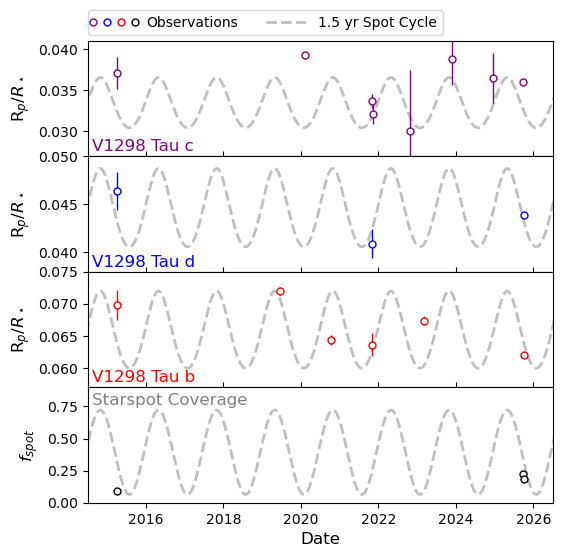

In [4]:
## set up demonstrative model
Ainit = 0.329
Pinit = 1.5
f0init = 0.393
t0init = 0.8
r0cinit = 0.03
r0dinit = 0.040
r0binit = 0.0591

theta_init = np.array([Ainit, Pinit, f0init, t0init, r0cinit, r0dinit, r0binit])
labels = np.array(['A','P','f0','t0','r0c','r0d','r0b'])

f_init, rp_c_init, rp_d_init, rp_b_init = get_models(theta_init, x, y)
f_initlong, rp_c_initlong, rp_d_initlong, rp_b_initlong = get_models(theta_init, xlong, y, long=True)

markers = ['o','o','o','o']
colors = ['purple','blue','red','black']

fig, ax = plt.subplots(figsize=(6,6), nrows=4, sharex=True)
plt.subplots_adjust(hspace=0.)
# row 1, planet c
ax[0].plot(2015.25+xlong, rp_c_initlong, c='gray', ls='--', lw=2, alpha=0.5)
ax[0].errorbar(2015.25+dates/365.0, Rc, Rcerr, ls='None', marker='o', ms=5, lw=1, c='purple', mec='purple', mfc='white')
ax[0].set_ylabel(r'R$_{p} / R_\star$', fontsize=12)
ax[0].tick_params(axis='x', which='both', direction='in', labelbottom=False)

# row 2, planet d
ax[1].plot(2015.25+xlong, rp_d_initlong, c='gray', ls='--', lw=2, alpha=0.5)
ax[1].errorbar(2015.25+dates/365.0, Rd, Rderr, ls='None', marker='o', ms=5, lw=1, c='blue', mec='blue', mfc='white')
ax[1].set_ylabel(r'R$_{p} / R_\star$', fontsize=12)
ax[1].tick_params(axis='x', which='both', direction='in', labelbottom=False)

# row 3, planet b
ax[2].plot(2015.25+xlong, rp_b_initlong, c='gray', ls='--', lw=2, alpha=0.5)
ax[2].errorbar(2015.25+dates/365.0, Rb, Rberr, ls='None', marker='o', ms=5, lw=1, c='red', mec='red', mfc='white')
ax[2].set_ylabel(r'R$_{p} / R_\star$', fontsize=12)
ax[2].tick_params(axis='x', which='both', direction='in', labelbottom=False)

# row 0, fspot
ax[3].plot(2015.25+xlong, f_initlong, c='gray', ls='--', lw=2, alpha=0.5)
ax[3].errorbar(2015.25+x, fall, fallerr, ls='None', marker='o', ms=5, lw=1, c='black', mec='black', mfc='white')
ax[3].set_ylabel(r'$f_{spot}$', fontsize=12)
ax[3].set_xlabel('Date', fontsize=12)

ax[3].set_xlim(2014.5,2026.5)


handles = [
    mlines.Line2D([], [], color=c, markerfacecolor='white', marker=m,
                  linestyle="None", markersize=5)
    for m, c in zip(markers, colors)
]
multi = tuple(handles)

ax[0].legend(loc=(0,1.05), ncol=2,
    handles=[multi,mlines.Line2D([], [], color="gray", ls='--', lw=2, alpha=0.5, label="1.5 yr Spot Cycle")],
    labels=["Observations", "1.5 yr Spot Cycle"],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=1)},
    handlelength=3,
)
ax[0].set_ylim(0.027,0.041)
ax[1].set_ylim(0.038,0.05)
ax[2].set_ylim(0.057,0.075)
ax[3].set_ylim(0,0.9)
ax[0].text(0.01, 0.045, 'V1298 Tau c', fontsize=12, c='purple', transform=ax[0].transAxes)
ax[1].text(0.01, 0.045, 'V1298 Tau d', fontsize=12, c='blue', transform=ax[1].transAxes)
ax[2].text(0.01, 0.045, 'V1298 Tau b', fontsize=12, c='red', transform=ax[2].transAxes)
ax[3].text(0.01, 0.85, 'Starspot Coverage', fontsize=12, c='gray', transform=ax[3].transAxes)

plt.savefig('./figures/Figure11_rpvar_published_forward.pdf', dpi=600, bbox_inches='tight')
plt.show()